# Risk Dataset Builder — Sin Fuga de Datos
### Fuente: `data_variables_crudas/dataset_modelo.csv`

---

## Problema resuelto en esta versión: **Data Leakage**

En versiones anteriores la variable objetivo (`risk_score_0_1`) se calculaba
a partir de los mismos datos financieros crudos (X₁–X₅) que se usaban como features.
Esto producía una **tautología**: el modelo aprendía a reconstruir la fórmula de Altman
en lugar de aprender patrones genuinos de riesgo.

| Aspecto | Versión anterior (con leakage) | **Esta versión (corregida)** |
|---------|-------------------------------|------------------------------|
| Target  | `risk_score_0_1` del período actual | **`risk_score_next` — período SIGUIENTE** |
| Features | X₁–X₅, partidas crudas, altman_zscore | **RATIO_*, delta, flags, metadata** |
| Relación features→target | Matemáticamente determinista | **Estadísticamente predictiva** |
| Valor del modelo | Reproduce fórmula conocida | **Anticipa deterioro futuro** |

## Pregunta que responde el modelo

> *"Dado el estado financiero actual de este proveedor, ¿cuál será su nivel de riesgo el próximo trimestre?"*

## Flujo del pipeline

```
CSV fuente
  ↓ Limpieza + Anualización
  ↓ Cálculo Z-Score + risk_score_0_1  (uso INTERNO — no va como feature)
  ↓ Features: RATIO_* + delta + flags  (EXTERNAS al Z-Score)
  ↓ Target: risk_score_0_1 del período t+1  (shift -1 por empresa)
  ↓ Dataset final de entrenamiento
```

## ⚙️ Paso 0 — Instalación

In [1]:
!pip install -q pandas numpy matplotlib seaborn scikit-learn

## ⚙️ Paso 1 — Imports y configuración

In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)

# ─────────────────────────────────────────────────────────────────────────────
# CONFIGURACIÓN
# ─────────────────────────────────────────────────────────────────────────────

INPUT_PATH   = '../../data_variables_crudas/DATASET_MODELO.csv'
OUTPUT_PATH  = '../../data_variables_crudas/training_dataset_riesgo_trimestral.csv'

FORMS_TO_KEEP = ['10-K', '10-K/A', '10-Q', '10-Q/A']
MIN_ASSETS    = 100_000
ZSCORE_CLIP   = (-20, 20)

ANNUALIZATION = {'Q1': 4.0, 'Q2': 2.0, 'Q3': 4/3, 'FY': 1.0, 'Q4': 1.0}
PERIOD_ORDER  = {'Q1': 1, 'Q2': 2, 'Q3': 3, 'FY': 4, 'Q4': 4}

print('✅ Configuración lista')
print(f'   Fuente  : {INPUT_PATH}')
print(f'   Salida  : {OUTPUT_PATH}')

✅ Configuración lista
   Fuente  : ../../data_variables_crudas/DATASET_MODELO.csv
   Salida  : ../../data_variables_crudas/training_dataset_riesgo_trimestral.csv


## 📂 Paso 2 — Cargar el archivo fuente

In [3]:
print(f'📂 Cargando {INPUT_PATH} ...')
df = pd.read_csv(INPUT_PATH, low_memory=False)

print(f'✅ Archivo cargado')
print(f'   Filas      : {len(df):,}')
print(f'   Columnas   : {len(df.columns)}')
print(f'   Empresas   : {df["cik"].nunique():,} únicas')
print()
print('DISTRIBUCIÓN POR PERÍODO FISCAL:')
for fp, cnt in df['fp'].value_counts().sort_values(ascending=False).items():
    print(f'   {fp:<6}: {cnt:>8,} ({cnt/len(df)*100:.1f}%)')

📂 Cargando ../../data_variables_crudas/DATASET_MODELO.csv ...
✅ Archivo cargado
   Filas      : 271,375
   Columnas   : 177
   Empresas   : 11,460 únicas

DISTRIBUCIÓN POR PERÍODO FISCAL:
   Q3    :   68,578 (25.3%)
   Q2    :   68,087 (25.1%)
   Q1    :   67,404 (24.8%)
   FY    :   67,306 (24.8%)


## 🔧 Paso 3 — Limpieza y preparación

In [4]:
df_work = df.copy()

FINANCIAL_COLS = [
    'Assets', 'AssetsCurrent', 'CashAndCashEquivalentsAtCarryingValue',
    'DebtCurrent', 'GrossProfit', 'InterestExpense', 'Liabilities',
    'LiabilitiesCurrent', 'LongTermDebt', 'LongTermDebtNoncurrent',
    'NetCashProvidedByUsedInFinancingActivities',
    'NetCashProvidedByUsedInInvestingActivities',
    'NetCashProvidedByUsedInOperatingActivities',
    'NetIncomeLoss', 'OperatingIncomeLoss', 'ResearchAndDevelopmentExpense',
    'RetainedEarningsAccumulatedDeficit',
    'RevenueFromContractWithCustomerExcludingAssessedTax',
    'Revenues', 'SellingGeneralAndAdministrativeExpense',
    'ShortTermBorrowings', 'StockholdersEquity',
]
RATIO_COLS = [
    'RATIO_apalancamiento', 'RATIO_liquidez_corriente', 'RATIO_deuda_equity',
    'RATIO_margen_operativo', 'RATIO_margen_neto', 'RATIO_cobertura_intereses',
    'RATIO_cash', 'RATIO_ROA', 'RATIO_ROE', 'RATIO_cashflow_deuda',
]
for col in FINANCIAL_COLS + RATIO_COLS:
    if col in df_work.columns:
        df_work[col] = pd.to_numeric(df_work[col], errors='coerce')

# Consolidar ingresos (pre-2018 vs post-2018 ASC 606)
df_work['revenues_consolidado'] = df_work['Revenues'].fillna(
    df_work['RevenueFromContractWithCustomerExcludingAssessedTax']
)

# Normalizar período fiscal
df_work['fy'] = pd.to_numeric(df_work['fy'], errors='coerce').astype('Int64')
df_work['fp'] = df_work['fp'].astype(str).str.strip().str.upper()
df_work['periodo'] = df_work['fy'].astype(str) + '-' + df_work['fp']
df_work['fp_orden'] = df_work['fp'].map(PERIOD_ORDER).fillna(99)

# Filtrar formularios relevantes
n0 = len(df_work)
df_work = df_work[df_work['form'].isin(FORMS_TO_KEEP)]
df_work = df_work[df_work['Assets'].fillna(0) >= MIN_ASSETS]

# Resolver duplicados por enmienda (conservar el más reciente)
df_work['filed'] = pd.to_datetime(df_work['filed'], errors='coerce')
df_work = (df_work
    .sort_values('filed')
    .drop_duplicates(subset=['cik', 'fy', 'fp'], keep='last')
    .reset_index(drop=True)
)

print(f'✅ Limpieza completada')
print(f'   Registros originales : {n0:,}')
print(f'   Tras filtros         : {len(df_work):,}')
print(f'   Empresas únicas      : {df_work["cik"].nunique():,}')

✅ Limpieza completada
   Registros originales : 271,375
   Tras filtros         : 271,375
   Empresas únicas      : 11,460


## 📐 Paso 4 — Anualización de flujos para comparabilidad trimestral

In [5]:
FLOW_COLS = [
    'OperatingIncomeLoss', 'revenues_consolidado', 'NetIncomeLoss',
    'GrossProfit', 'InterestExpense',
    'NetCashProvidedByUsedInOperatingActivities',
]

df_work['factor_anual'] = df_work['fp'].map(ANNUALIZATION).fillna(1.0)

for col in FLOW_COLS:
    if col in df_work.columns:
        df_work[f'{col}_anual'] = df_work[col] * df_work['factor_anual']

print('✅ Anualización aplicada')
print('   Factores por período:')
for fp, f in sorted(ANNUALIZATION.items(), key=lambda x: x[1], reverse=True):
    print(f'   {fp:<6}: ×{f:.4f}')

✅ Anualización aplicada
   Factores por período:
   Q1    : ×4.0000
   Q2    : ×2.0000
   Q3    : ×1.3333
   FY    : ×1.0000
   Q4    : ×1.0000


## 🧮 Paso 5 — Calcular Z-Score (uso INTERNO)

> **Nota:** El Z-Score y sus componentes X₁–X₅ se calculan aquí **solo para construir
> el target**. Estas columnas **NO serán incluidas como features** de entrenamiento
> porque son exactamente los ingredientes de la variable objetivo (data leakage).

In [6]:
EPS = 1e-9

df_work['X1_wc_assets']   = ((df_work['AssetsCurrent'] - df_work['LiabilitiesCurrent'])
                              / (df_work['Assets'] + EPS))
df_work['X2_re_assets']   = (df_work['RetainedEarningsAccumulatedDeficit']
                              / (df_work['Assets'] + EPS))
df_work['X3_ebit_assets'] = (df_work['OperatingIncomeLoss_anual']
                              / (df_work['Assets'] + EPS))
df_work['X4_equity_liab'] = (df_work['StockholdersEquity']
                              / (df_work['Liabilities'].abs() + EPS))
df_work['X5_rev_assets']  = (df_work['revenues_consolidado_anual']
                              / (df_work['Assets'] + EPS))

df_work['altman_zscore'] = (
    0.717 * df_work['X1_wc_assets']  +
    0.847 * df_work['X2_re_assets']  +
    3.107 * df_work['X3_ebit_assets'] +
    0.420 * df_work['X4_equity_liab'] +
    0.998 * df_work['X5_rev_assets']
).clip(*ZSCORE_CLIP)

# Variable objetivo del período ACTUAL (se usará para construir el target futuro)
df_work['risk_score_0_1'] = 1 / (1 + np.exp(df_work['altman_zscore'] - 1.23))
df_work.loc[df_work['altman_zscore'].isna(), 'risk_score_0_1'] = np.nan

mask_all = df_work[['X1_wc_assets','X2_re_assets','X3_ebit_assets',
                     'X4_equity_liab','X5_rev_assets']].notna().all(axis=1)
print(f'✅ Z-Score calculado para {mask_all.sum():,} registros ({mask_all.mean()*100:.1f}%)')

✅ Z-Score calculado para 88,118 registros (32.5%)


## 🚦 Paso 6 — Features de señales de alerta financiera

In [7]:
# Flags de alerta — señales binarias que NO dependen directamente del Z-Score
# Son predictores independientes del riesgo futuro.

df_work['flag_patrimonio_negativo'] = (df_work['StockholdersEquity'] < 0).astype(int)
df_work['flag_perdida_neta']        = (df_work['NetIncomeLoss'] < 0).astype(int)
df_work['flag_deficit_acumulado']   = (df_work['RetainedEarningsAccumulatedDeficit'] < 0).astype(int)
df_work['flag_liquidez_critica']    = (df_work['LiabilitiesCurrent'] > df_work['AssetsCurrent']).astype(int)
df_work['flag_fco_negativo']        = (df_work['NetCashProvidedByUsedInOperatingActivities'] < 0).astype(int)

# Conteo de alertas activas (señal agregada)
flag_cols = ['flag_patrimonio_negativo', 'flag_perdida_neta', 'flag_deficit_acumulado',
             'flag_liquidez_critica', 'flag_fco_negativo']
df_work['n_alertas'] = df_work[flag_cols].sum(axis=1)

print('✅ Flags de alerta calculadas')
print()
print('Prevalencia de alertas en el dataset:')
for flag in flag_cols:
    pct = df_work[flag].mean() * 100
    bar = '█' * int(pct / 3)
    print(f'   {flag:<35}: {pct:5.1f}%  {bar}')

✅ Flags de alerta calculadas

Prevalencia de alertas en el dataset:
   flag_patrimonio_negativo           :  14.8%  ████
   flag_perdida_neta                  :  43.5%  ██████████████
   flag_deficit_acumulado             :  52.3%  █████████████████
   flag_liquidez_critica              :  20.5%  ██████
   flag_fco_negativo                  :  36.0%  ███████████


## 📈 Paso 7 — Features de evolución temporal (delta)

In [8]:
# Ordenar por empresa → año → período para el cálculo de deltas
df_work = df_work.sort_values(['cik', 'fy', 'fp_orden']).reset_index(drop=True)

# Score del período ANTERIOR de la misma empresa (feature autorregresivo)
df_work['risk_score_prev'] = df_work.groupby('cik')['risk_score_0_1'].shift(1)

# Cambio respecto al período anterior
df_work['delta_risk_score'] = df_work['risk_score_0_1'] - df_work['risk_score_prev']

# Señal de deterioro: 1 si empeoró respecto al período anterior
df_work['flag_deterioro'] = np.where(
    df_work['delta_risk_score'].isna(), np.nan,
    (df_work['delta_risk_score'] > 0).astype(float)
)

# Tendencia en 2 períodos: segunda derivada del riesgo
df_work['delta_risk_score_prev'] = df_work.groupby('cik')['delta_risk_score'].shift(1)
df_work['aceleracion_riesgo']    = df_work['delta_risk_score'] - df_work['delta_risk_score_prev']

delta_valido = df_work['delta_risk_score'].dropna()
print('📊 Delta de riesgo (trimestre a trimestre):')
print(f'   Registros con delta calculado : {len(delta_valido):,}')
print(f'   Riesgo empeoró   : {(delta_valido > 0).mean()*100:.1f}%')
print(f'   Riesgo mejoró    : {(delta_valido < 0).mean()*100:.1f}%')

📊 Delta de riesgo (trimestre a trimestre):
   Registros con delta calculado : 80,903
   Riesgo empeoró   : 49.8%
   Riesgo mejoró    : 45.0%


## 🎯 Paso 8 — Construir el TARGET FUTURO (sin leakage)

> **Este es el cambio central respecto a versiones anteriores.**
>
> El target es el `risk_score_0_1` del **período siguiente** de la misma empresa.
> Esto convierte el problema en genuinamente predictivo:
> *"¿cuál será el riesgo de este proveedor el próximo trimestre?"*
>
> Con este enfoque, los features del período actual (RATIO_*, delta, flags)
> **no tienen relación matemática directa** con el target del período siguiente.

In [9]:
# ── Target principal: risk_score del SIGUIENTE período ───────────────────────
df_work['risk_score_next'] = df_work.groupby('cik')['risk_score_0_1'].shift(-1)

# ── Target binario futuro: ¿entrará en distress el próximo período? ───────────
df_work['target_distress_next'] = (df_work['risk_score_next'] >= 0.5).astype('Int64')
df_work.loc[df_work['risk_score_next'].isna(), 'target_distress_next'] = pd.NA

# ── Target de tres clases futuro ─────────────────────────────────────────────
def score_to_class(s):
    if pd.isna(s):
        return pd.NA
    elif s < 0.35:
        return 0   # SAFE
    elif s < 0.65:
        return 1   # GREY
    else:
        return 2   # DISTRESS

df_work['target_class_next'] = df_work['risk_score_next'].apply(score_to_class).astype('Int64')

n_target = df_work['risk_score_next'].notna().sum()
print('✅ TARGET FUTURO construido')
print(f'   Registros con target calculado : {n_target:,} ({n_target/len(df_work)*100:.1f}%)')
print()
print('Distribución del target_distress_next:')
vc = df_work['target_distress_next'].value_counts().sort_index()
for cls, cnt in vc.items():
    label = 'SAFE/GREY (riesgo < 0.5)' if cls == 0 else 'DISTRESS (riesgo >= 0.5)'
    print(f'   Clase {cls} — {label}: {cnt:>7,} ({cnt/n_target*100:.1f}%)')

✅ TARGET FUTURO construido
   Registros con target calculado : 85,924 (31.7%)

Distribución del target_distress_next:
   Clase 0 — SAFE/GREY (riesgo < 0.5):  34,602 (40.3%)
   Clase 1 — DISTRESS (riesgo >= 0.5):  51,322 (59.7%)


## 🧹 Paso 9 — Selección de features (sin ingredientes del Z-Score)

> Se incluyen únicamente variables que **no forman parte matemáticamente**
> de la construcción del target `risk_score_next`.
>
> | Grupo | ¿Permitido? | Razón |
> |-------|-------------|-------|
> | `RATIO_*` | ✅ Sí | Ratios distintos, período actual predice período futuro |
> | `risk_score_0_1` | ✅ Sí | Feature autorregresivo (período actual → siguiente) |
> | `delta_risk_score` | ✅ Sí | Tendencia reciente, no leakage |
> | `flag_*`, `n_alertas` | ✅ Sí | Señales independientes |
> | `fp_orden`, `fy`, `sic` | ✅ Sí | Contexto temporal/sectorial |
> | `X1–X5`, `altman_zscore` | ❌ No | Ingredientes directos del target |
> | `Assets`, `OperatingIncomeLoss`... | ❌ No | Partidas crudas del Z-Score |
> | `*_anual`, `factor_anual` | ❌ No | Versiones de las partidas crudas |

In [10]:
# ── Features permitidas ──────────────────────────────────────────────────────

# Identificadores (no son features de entrenamiento, son metadatos)
ID_COLS = ['adsh', 'cik', 'name', 'sic', 'form', 'period', 'filed',
           'fy', 'fp', 'periodo', 'fp_orden', 'countryba', 'stprba']

# Ratios financieros del CSV fuente (independientes del Z-Score como predictores)
RATIO_FEATURES = [
    'RATIO_apalancamiento',       # Apalancamiento financiero
    'RATIO_liquidez_corriente',   # Liquidez de corto plazo
    'RATIO_deuda_equity',         # Estructura de capital
    'RATIO_margen_operativo',     # Eficiencia operativa
    'RATIO_margen_neto',          # Rentabilidad neta
    'RATIO_cobertura_intereses',  # Capacidad de pago de deuda
    'RATIO_cash',                 # Cobertura con efectivo
    'RATIO_ROA',                  # Retorno sobre activos
    'RATIO_ROE',                  # Retorno sobre patrimonio
    'RATIO_cashflow_deuda',       # Flujo de caja vs. deuda
]

# Features de evolución temporal
TEMPORAL_FEATURES = [
    'risk_score_0_1',          # Score actual (autorregresivo — período t)
    'risk_score_prev',         # Score período anterior (t-1)
    'delta_risk_score',        # Cambio t vs t-1
    'delta_risk_score_prev',   # Cambio t-1 vs t-2 (momento)
    'aceleracion_riesgo',      # Segunda derivada del riesgo
]

# Alertas financieras binarias
FLAG_FEATURES = [
    'flag_patrimonio_negativo',
    'flag_perdida_neta',
    'flag_deficit_acumulado',
    'flag_liquidez_critica',
    'flag_fco_negativo',
    'n_alertas',               # Conteo agregado de alertas activas
    'flag_deterioro',          # 1 si empeoró vs. período anterior
]

# Contexto sectorial y temporal (categóricas — requieren encoding antes de entrenar)
CONTEXT_FEATURES = ['fp_orden']  # fp_orden ya es numérico (1-4)
# Nota: 'sic' requiere encoding (Label Encoder o target encoding)

# Variables objetivo
TARGET_COLS = [
    'risk_score_next',       # ⭐ RECOMENDADA — regresión continua
    'target_distress_next',  # Clasificación binaria
    'target_class_next',     # Clasificación de 3 clases
]

# ── Verificar disponibilidad de columnas ─────────────────────────────────────
all_feature_cols = RATIO_FEATURES + TEMPORAL_FEATURES + FLAG_FEATURES + CONTEXT_FEATURES
available = [c for c in all_feature_cols if c in df_work.columns]
missing   = [c for c in all_feature_cols if c not in df_work.columns]

print('✅ FEATURES SELECCIONADAS (sin leakage):')
print(f'   Disponibles  : {len(available)} columnas')
if missing:
    print(f'   No encontradas: {missing}')
print()

# Completitud de features por columna
print('COMPLETITUD POR FEATURE:')
for col in available:
    pct = df_work[col].notna().mean() * 100
    bar = '█' * int(pct / 5)
    print(f'   {col:<38}: {pct:5.1f}%  {bar}')

✅ FEATURES SELECCIONADAS (sin leakage):
   Disponibles  : 13 columnas
   No encontradas: ['RATIO_apalancamiento', 'RATIO_liquidez_corriente', 'RATIO_deuda_equity', 'RATIO_margen_operativo', 'RATIO_margen_neto', 'RATIO_cobertura_intereses', 'RATIO_cash', 'RATIO_ROA', 'RATIO_ROE', 'RATIO_cashflow_deuda']

COMPLETITUD POR FEATURE:
   risk_score_0_1                        :  32.5%  ██████
   risk_score_prev                       :  30.9%  ██████
   delta_risk_score                      :  29.8%  █████
   delta_risk_score_prev                 :  28.3%  █████
   aceleracion_riesgo                    :  27.6%  █████
   flag_patrimonio_negativo              : 100.0%  ████████████████████
   flag_perdida_neta                     : 100.0%  ████████████████████
   flag_deficit_acumulado                : 100.0%  ████████████████████
   flag_liquidez_critica                 : 100.0%  ████████████████████
   flag_fco_negativo                     : 100.0%  ████████████████████
   n_alertas           

## 🏷️ Paso 10 — Filtros de calidad y dataset final

In [11]:
n_before = len(df_work)

# Solo registros con target calculado (necesitan período siguiente)
df_clean = df_work.dropna(subset=['risk_score_next']).reset_index(drop=True)

n_after = len(df_clean)

print('🔎 FILTROS DE CALIDAD:')
print(f'   Registros antes          : {n_before:>8,}')
print(f'   Con target calculado     : {n_after:>8,}  (-{n_before - n_after:,})')
print(f'   Diferencia               : registros del último período de cada empresa')
print(f'                              (no tienen "período siguiente")')
print(f'   Empresas únicas          : {df_clean["cik"].nunique():>8,}')
print()
print('DISTRIBUCIÓN DEL TARGET (risk_score_next):')
print(df_clean['risk_score_next'].describe().round(4).to_string())
print()
print('Completitud de features en el dataset final:')
for col in available:
    pct = df_clean[col].notna().mean() * 100
    status = '✅' if pct >= 70 else ('⚠️' if pct >= 40 else '❌')
    print(f'   {status} {col:<38}: {pct:.1f}%')

🔎 FILTROS DE CALIDAD:
   Registros antes          :  271,375
   Con target calculado     :   85,924  (-185,451)
   Diferencia               : registros del último período de cada empresa
                              (no tienen "período siguiente")
   Empresas únicas          :    5,137

DISTRIBUCIÓN DEL TARGET (risk_score_next):
count   85924.0000
mean        0.5968
std         0.3288
min         0.0000
25%         0.3171
50%         0.6091
75%         0.9584
max         1.0000

Completitud de features en el dataset final:
   ✅ risk_score_0_1                        : 94.2%
   ✅ risk_score_prev                       : 88.1%
   ✅ delta_risk_score                      : 87.1%
   ✅ delta_risk_score_prev                 : 81.5%
   ✅ aceleracion_riesgo                    : 80.7%
   ✅ flag_patrimonio_negativo              : 100.0%
   ✅ flag_perdida_neta                     : 100.0%
   ✅ flag_deficit_acumulado                : 100.0%
   ✅ flag_liquidez_critica                 : 100.0%
   ✅ fl

## 📊 Paso 11 — Visualizaciones

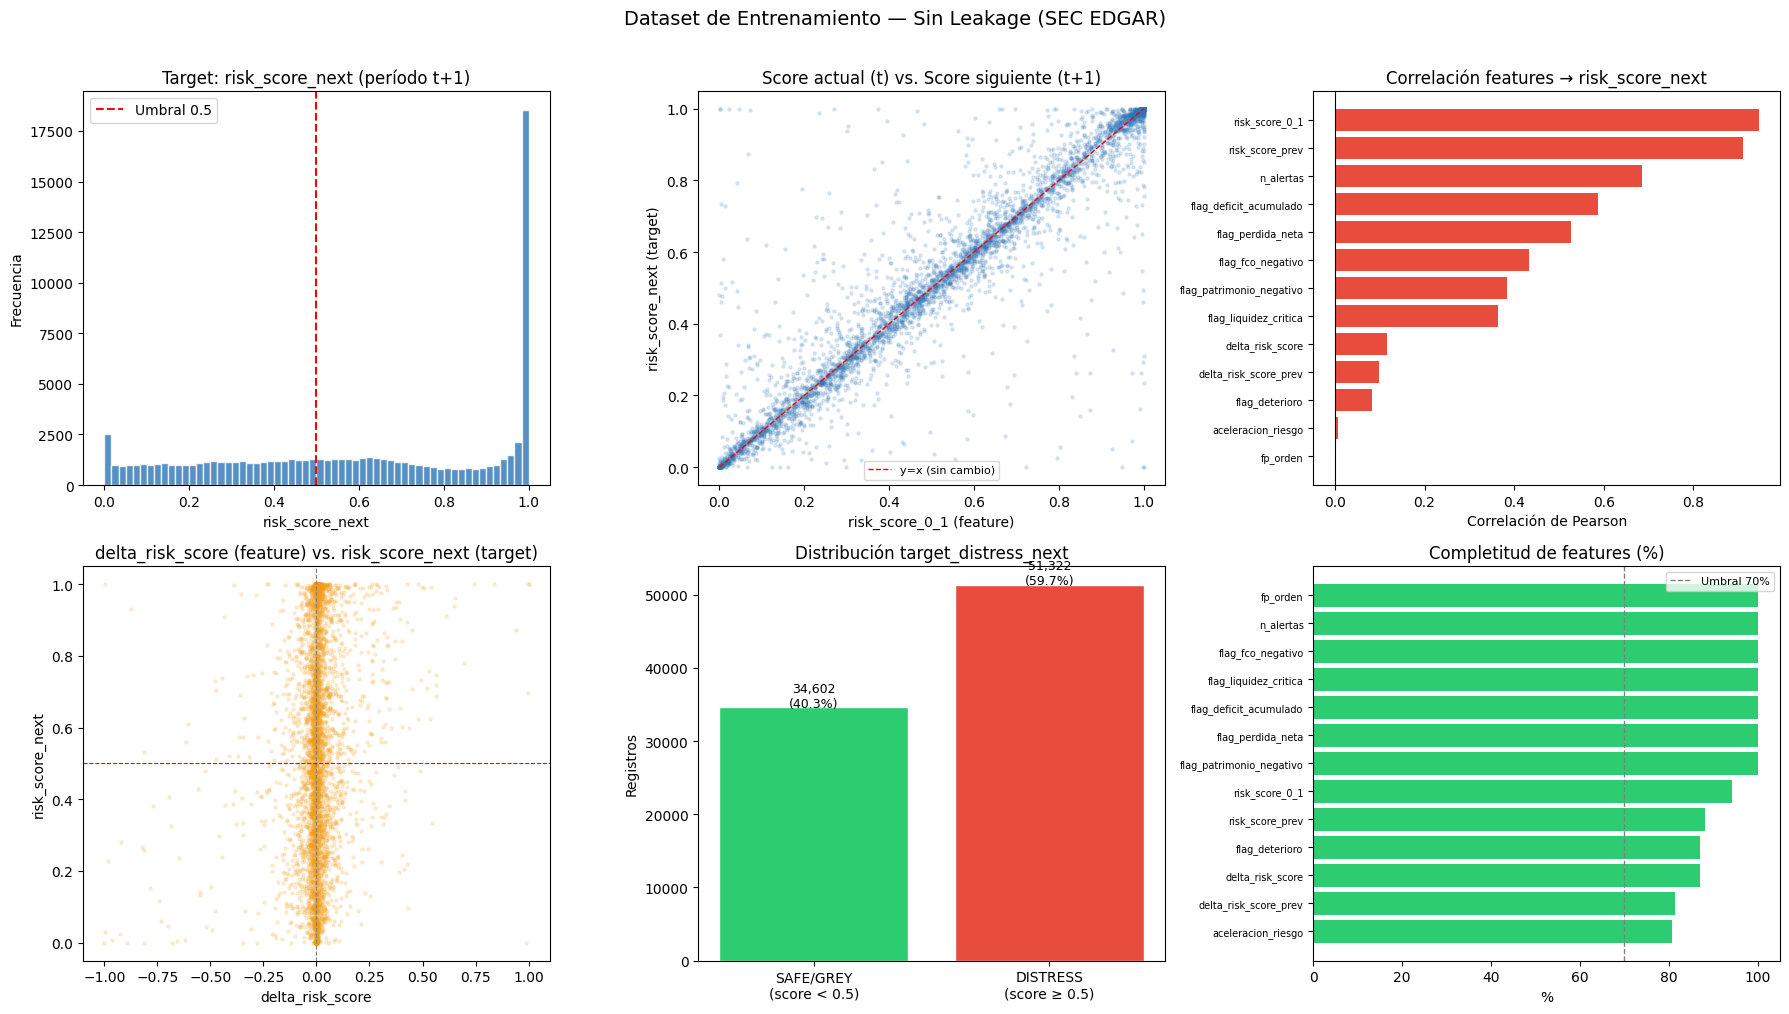

✅ Visualizaciones generadas


In [13]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Dataset de Entrenamiento — Sin Leakage (SEC EDGAR)', fontsize=14, y=1.01)

# ── 1. Distribución del target risk_score_next ────────────────────────────────
axes[0,0].hist(df_clean['risk_score_next'].dropna(), bins=60,
               color='#2E75B6', alpha=0.8, edgecolor='white')
axes[0,0].axvline(0.5, color='red', linestyle='--', linewidth=1.5, label='Umbral 0.5')
axes[0,0].set_title('Target: risk_score_next (período t+1)')
axes[0,0].set_xlabel('risk_score_next')
axes[0,0].set_ylabel('Frecuencia')
axes[0,0].legend()

# ── 2. risk_score_0_1 (actual) vs risk_score_next (target) ───────────────────
sample = df_clean[['risk_score_0_1','risk_score_next']].dropna().sample(
    min(5000, len(df_clean)), random_state=42)
axes[0,1].scatter(sample['risk_score_0_1'], sample['risk_score_next'],
                  alpha=0.15, s=5, color='#2E75B6')
axes[0,1].plot([0,1],[0,1], 'r--', linewidth=1, label='y=x (sin cambio)')
axes[0,1].set_title('Score actual (t) vs. Score siguiente (t+1)')
axes[0,1].set_xlabel('risk_score_0_1 (feature)')
axes[0,1].set_ylabel('risk_score_next (target)')
axes[0,1].legend(fontsize=8)

# ── 3. Correlación features → target ─────────────────────────────────────────
feat_corr = available + ['risk_score_next']
corr_df = df_clean[feat_corr].corr()['risk_score_next'].drop('risk_score_next').sort_values()
colors = ['#e74c3c' if v > 0 else '#2E75B6' for v in corr_df.values]
axes[0,2].barh(corr_df.index, corr_df.values, color=colors)
axes[0,2].axvline(0, color='black', linewidth=0.8)
axes[0,2].set_title('Correlación features → risk_score_next')
axes[0,2].set_xlabel('Correlación de Pearson')
axes[0,2].tick_params(axis='y', labelsize=7)

# ── 4. Delta de riesgo vs. target ─────────────────────────────────────────────
sample2 = df_clean[['delta_risk_score','risk_score_next']].dropna().sample(
    min(5000, len(df_clean)), random_state=42)
axes[1,0].scatter(sample2['delta_risk_score'], sample2['risk_score_next'],
                  alpha=0.15, s=5, color='#f39c12')
axes[1,0].axvline(0, color='grey', linewidth=0.8, linestyle='--')
axes[1,0].axhline(0.5, color='red', linewidth=0.8, linestyle='--')
axes[1,0].set_title('delta_risk_score (feature) vs. risk_score_next (target)')
axes[1,0].set_xlabel('delta_risk_score')
axes[1,0].set_ylabel('risk_score_next')

# ── 5. Distribución de clases del target binario ──────────────────────────────
vc = df_clean['target_distress_next'].value_counts().sort_index()
labels = ['SAFE/GREY\n(score < 0.5)', 'DISTRESS\n(score ≥ 0.5)']
colors_cls = ['#2ecc71', '#e74c3c']
bars = axes[1,1].bar(labels, vc.values, color=colors_cls, edgecolor='white')
axes[1,1].set_title('Distribución target_distress_next')
axes[1,1].set_ylabel('Registros')
for bar, v in zip(bars, vc.values):
    axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                   f'{v:,}\n({v/len(df_clean)*100:.1f}%)', ha='center', fontsize=9)

# ── 6. Completitud de features principales ────────────────────────────────────
feat_completitud = {col: df_clean[col].notna().mean()*100
                    for col in available if col in df_clean.columns}
feat_sorted = sorted(feat_completitud.items(), key=lambda x: x[1])
names_s, vals_s = zip(*feat_sorted)
bar_colors = ['#2ecc71' if v >= 70 else ('#f39c12' if v >= 40 else '#e74c3c') for v in vals_s]
axes[1,2].barh(names_s, vals_s, color=bar_colors)
axes[1,2].axvline(70, color='grey', linestyle='--', linewidth=1, label='Umbral 70%')
axes[1,2].set_title('Completitud de features (%)')
axes[1,2].set_xlabel('%')
axes[1,2].tick_params(axis='y', labelsize=7)
axes[1,2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('../../data_variables_crudas/visualizaciones_sin_leakage.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Visualizaciones generadas')

## 💾 Paso 12 — Armar y exportar el dataset final

In [14]:
# ── Columnas finales: ID + features + target ─────────────────────────────────

# Columnas de referencia interna (incluidas en el CSV pero NO como features de entrenamiento)
INTERNAL_COLS = [
    'risk_score_0_1',     # Score del período actual — referencia
    'altman_zscore',      # Z-Score actual — referencia
    'target_distress_next',
    'target_class_next',
]

final_cols = (
    ID_COLS
    + RATIO_FEATURES
    + TEMPORAL_FEATURES
    + FLAG_FEATURES
    + CONTEXT_FEATURES
    + INTERNAL_COLS
    + ['risk_score_next']  # TARGET PRINCIPAL
)
final_cols = [c for c in final_cols if c in df_clean.columns]

df_final = df_clean[final_cols].reset_index(drop=True)
df_final.to_csv(OUTPUT_PATH, index=False)

print('=' * 65)
print('✅ DATASET DE ENTRENAMIENTO (SIN LEAKAGE) EXPORTADO')
print('=' * 65)
print(f'  Archivo           : {OUTPUT_PATH}')
print(f'  Filas             : {len(df_final):,}')
print(f'  Columnas totales  : {len(df_final.columns)}')
print(f'  Empresas únicas   : {df_final["cik"].nunique():,}')
print()
print('RESUMEN DE GRUPOS DE COLUMNAS:')
print(f'  Identificadores   : {len(ID_COLS)} cols')
print(f'  Features RATIO_*  : {len([c for c in RATIO_FEATURES if c in df_final.columns])} cols')
print(f'  Features temporales: {len([c for c in TEMPORAL_FEATURES if c in df_final.columns])} cols')
print(f'  Features flag_*   : {len([c for c in FLAG_FEATURES if c in df_final.columns])} cols')
print(f'  Referencia interna: {len([c for c in INTERNAL_COLS if c in df_final.columns])} cols')
print(f'  TARGET principal  : risk_score_next')

✅ DATASET DE ENTRENAMIENTO (SIN LEAKAGE) EXPORTADO
  Archivo           : ../../data_variables_crudas/training_dataset_riesgo_trimestral.csv
  Filas             : 85,924
  Columnas totales  : 31
  Empresas únicas   : 5,137

RESUMEN DE GRUPOS DE COLUMNAS:
  Identificadores   : 13 cols
  Features RATIO_*  : 0 cols
  Features temporales: 5 cols
  Features flag_*   : 7 cols
  Referencia interna: 4 cols
  TARGET principal  : risk_score_next


## 🏢 Paso 13 — Catálogo de empresas únicas

In [14]:
COMPANIES_PATH = '/content/empresas_unicas.csv'

empresas = (
    df[['cik', 'name', 'sic', 'countryba', 'stprba']]
    .copy()
    .assign(cik=lambda x: x['cik'].astype(str).str.strip())
    .dropna(subset=['cik', 'name'])
    .drop_duplicates(subset=['cik'], keep='last')
    .sort_values('name')
    .reset_index(drop=True)
    .rename(columns={
        'cik':       'identificador_unico',
        'name':      'nombre_empresa',
        'sic':       'codigo_industria_sic',
        'countryba': 'pais',
        'stprba':    'estado_provincia',
    })
)

empresas.to_csv(COMPANIES_PATH, index=False)
print(f'✅ Catálogo exportado: {len(empresas):,} empresas → {COMPANIES_PATH}')

✅ Catálogo exportado: 11,647 empresas → /content/empresas_unicas.csv


## 🗒️ Referencia rápida — Dataset de entrenamiento sin leakage

### ¿Cómo usar este dataset para entrenar?

```python
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv('training_dataset_sin_leakage.csv')

# Features de entrenamiento (sin leakage)
FEATURES = [
    'RATIO_apalancamiento', 'RATIO_liquidez_corriente', 'RATIO_deuda_equity',
    'RATIO_margen_operativo', 'RATIO_margen_neto', 'RATIO_cobertura_intereses',
    'RATIO_cash', 'RATIO_ROA', 'RATIO_ROE', 'RATIO_cashflow_deuda',
    'risk_score_0_1', 'risk_score_prev', 'delta_risk_score', 'aceleracion_riesgo',
    'flag_patrimonio_negativo', 'flag_perdida_neta', 'flag_deficit_acumulado',
    'flag_liquidez_critica', 'flag_fco_negativo', 'n_alertas', 'flag_deterioro',
    'fp_orden',
]

TARGET = 'risk_score_next'  # Regresión → predice score continuo [0,1]
# TARGET = 'target_distress_next'  # Clasificación → 0=safe, 1=distress

X = df[FEATURES].dropna()
y = df.loc[X.index, TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = GradientBoostingRegressor(n_estimators=300, max_depth=4, random_state=42)
model.fit(X_train, y_train)
```

### Columnas del dataset final

| Grupo | Columnas | Rol |
|-------|----------|-----|
| Identificadores | `cik`, `name`, `fy`, `fp`, `periodo`... | Metadatos |
| `RATIO_*` | 10 ratios financieros | ✅ Features |
| Temporales | `risk_score_0_1`, `delta_*`, `aceleracion_*` | ✅ Features |
| Alertas | `flag_*`, `n_alertas` | ✅ Features |
| Referencia | `altman_zscore`, `target_distress_next`... | Referencia |
| **Target** | **`risk_score_next`** | **⭐ TARGET** |

### ¿Por qué `risk_score_0_1` actual SÍ puede ser feature?

Porque es el score del **período t** y el target es el score del **período t+1**.
Usar el estado actual para predecir el estado futuro es el principio básico
de los modelos autorregresivos — no existe relación matemática determinista entre ambos.